In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib

In [4]:
print("Loading DNN Dataset...")
df = pd.read_csv('DNN-EdgeIIoT-dataset.csv', encoding="latin1")
df.head(10)

Loading DNN Dataset...


C:\Users\vashi\AppData\Local\Temp\ipykernel_6108\2066576125.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,11,13,14,15,16,17,20,31,32,34,39,45,49,50,51,54,55,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DNN-EdgeIIoT-dataset.csv', encoding="latin1")


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0.0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0.0,Normal
5,2021 11:44:10.166159000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
6,2021 11:44:10.166968000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
7,2021 11:44:10.167072000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
8,2021 11:44:10.169612000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
9,2021 11:44:10.169644000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Normal


In [5]:
df.isna().sum()

frame.time               426
ip.src_host           157698
ip.dst_host           193432
arp.dst.proto_ipv4    201867
arp.opcode            201967
                       ...  
mbtcp.len             202020
mbtcp.trans_id        202020
mbtcp.unit_id         202020
Attack_label          202020
Attack_type           202020
Length: 63, dtype: int64

In [7]:
# 1. Sirf wahi columns select karo jo humne upar decide ki hain (plus target label)
selected_columns = [
    'arp.opcode', 'http.content_length', 'tcp.ack', 'tcp.connection.fin', 
    'tcp.connection.syn', 'tcp.connection.synack', 'tcp.dstport', 'tcp.flags', 
    'tcp.len', 'udp.port', 'udp.time_delta', 'mqtt.len', 'mqtt.msgtype', 
    'mqtt.proto_len', 'mbtcp.len', 'Attack_label'
]

# Naya dataframe sirf inhi columns ke sath
df_clean = df[selected_columns].copy()

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420269 entries, 0 to 2420268
Data columns (total 16 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   arp.opcode             object 
 1   http.content_length    float64
 2   tcp.ack                object 
 3   tcp.connection.fin     float64
 4   tcp.connection.syn     float64
 5   tcp.connection.synack  float64
 6   tcp.dstport            float64
 7   tcp.flags              float64
 8   tcp.len                float64
 9   udp.port               float64
 10  udp.time_delta         float64
 11  mqtt.len               object 
 12  mqtt.msgtype           float64
 13  mqtt.proto_len         float64
 14  mbtcp.len              float64
 15  Attack_label           float64
dtypes: float64(13), object(3)
memory usage: 295.4+ MB


In [17]:
df_clean.isnull().sum()

arp.opcode               201967
http.content_length      202018
tcp.ack                  202018
tcp.connection.fin       202019
tcp.connection.syn       202019
tcp.connection.synack    202019
tcp.dstport              202019
tcp.flags                202019
tcp.len                  202019
udp.port                 202019
udp.time_delta           202019
mqtt.len                 202019
mqtt.msgtype             202020
mqtt.proto_len           202020
mbtcp.len                202020
Attack_label             202020
dtype: int64

In [19]:
import numpy as np
import pandas as pd

# Assume 'df' is your DataFrame

# -------------------------------------------------------------
# Step 1: Convert all object columns to numeric (coerce errors to NaN)
# -------------------------------------------------------------
object_cols = ["tcp.ack", "mqtt.len"]  # Add column 0 if it has a name

for col in object_cols:
    if col in df.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# -------------------------------------------------------------
# Step 2: Fill Missing Values in Network / Protocol Features
# -------------------------------------------------------------
# Network protocol metrics missing = protocol was not active in this packet -> 0
protocol_cols = [
    "http.content_length",
    "tcp.ack",
    "tcp.connection.fin",
    "tcp.connection.syn",
    "tcp.connection.synack",
    "tcp.dstport",
    "tcp.flags",
    "tcp.len",
    "udp.port",
    "udp.time_delta",
    "mqtt.len",
    "mqtt.msgtype",
    "mqtt.proto_len",
    "mbtcp.len",
]

# Fill missing protocol features with 0
df[protocol_cols] = df_clean[protocol_cols].fillna(0)


# -------------------------------------------------------------
# Step 3: Handle the Target Label ('Attack_label')
# -------------------------------------------------------------
# If Attack_label has missing values, drop those specific rows
df_clean = df_clean.dropna(subset=["Attack_label"])

# Ensure Attack_label is integer (0 or 1)
df_clean["Attack_label"] = df_clean["Attack_label"].astype(int)

# -------------------------------------------------------------
# Step 4: Verify that no NaN values remain
# -------------------------------------------------------------
print("Remaining Missing Values:")
print(df_clean.isnull().sum())

Remaining Missing Values:
arp.opcode               0
http.content_length      0
tcp.ack                  0
tcp.connection.fin       0
tcp.connection.syn       0
tcp.connection.synack    0
tcp.dstport              0
tcp.flags                0
tcp.len                  0
udp.port                 0
udp.time_delta           0
mqtt.len                 0
mqtt.msgtype             0
mqtt.proto_len           0
mbtcp.len                0
Attack_label             0
dtype: int64


C:\Users\vashi\AppData\Local\Temp\ipykernel_6108\1496140063.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Attack_label"] = df_clean["Attack_label"].astype(int)


In [21]:
X = df_clean.drop(columns=['Attack_label']) 
y = df_clean["Attack_label"]

In [22]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Neural Networks ke liye zaroori hai)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = Sequential(
    [
        Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.30),
        Dense(64, activation="relu"),
        Dropout(0.25),
        Dense(32, activation="relu"),
        Dropout(0.15),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")])  # Binary classification ke liye sigmoid])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

C:\Users\vashi\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,  # Pata chalega ki LR kab drop hua
)

# -------------------------------------------------------------
# Step 4: Train the Model
# -------------------------------------------------------------
history = model.fit(X_train,y_train,validation_data=(X_test, y_test),epochs=50,  # Max epochs (Early stopping pehle hi rok dega agar improvement nahi hua)
    batch_size=32,callbacks=[early_stop, reduce_lr],verbose=1,)

Epoch 1/50
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 138s 2ms/step - accuracy: 0.9502 - loss: 0.1542 - val_accuracy: 0.9558 - val_loss: 0.1666 - learning_rate: 0.0010
Epoch 2/50
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 131s 2ms/step - accuracy: 0.9553 - loss: 0.1375 - val_accuracy: 0.9630 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 3/50
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 200s 3ms/step - accuracy: 0.9581 - loss: 0.1326 - val_accuracy: 0.9436 - val_loss: 0.1661 - learning_rate: 0.0010
Epoch 4/50
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 272s 5ms/step - accuracy: 0.9529 - loss: 0.1454 - val_accuracy: 0.9632 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 5/50
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 322s 5ms/step - accuracy: 0.9594 - loss: 0.1239 - val_accuracy: 0.9448 - val_loss: 0.1226 - learning_rate: 0.0010
Epoch 6/50
55453/55457 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9583 - loss: 0.1265  
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
55457/55457 ━━━━━━━━━━━━━━━━━━━━ 320s 5ms/

In [29]:
 # H5 format me model save karein
# model.save("edgeiiot_model.h5")
print("Model .h5 format me successfully save ho gaya!")

Model .h5 format me successfully save ho gaya!


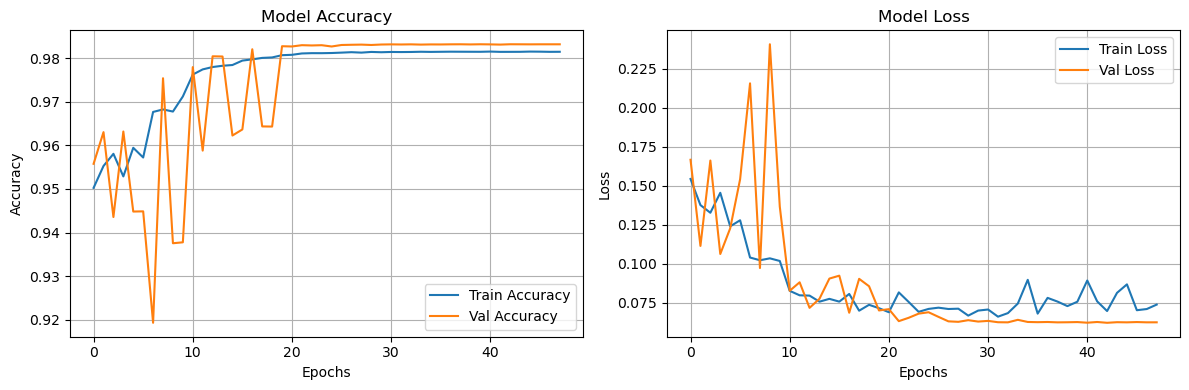

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_performance_graph.png", dpi=300)
plt.show()

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Predictions nikalen
y_pred_probs = model.predict(X_test)

# Binary classification ke liye:
y_pred = (y_pred_probs > 0.5).astype(int) 

# Multi-class ke liye (agar attack_type kar rahe ho):
# y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Confusion Matrix Print karein
cm = confusion_matrix(y_test, y_pred)
print("=== FINAL THINNED CONFUSION MATRIX ===")
print(cm)

# 3. Precision, Recall, F1-Score Check karein
print("\n=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=4))

13865/13865 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step
=== FINAL THINNED CONFUSION MATRIX ===
[[321348   1881]
 [  5580 114841]]

=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9829    0.9942    0.9885    323229
           1     0.9839    0.9537    0.9685    120421

    accuracy                         0.9832    443650
   macro avg     0.9834    0.9739    0.9785    443650
weighted avg     0.9832    0.9832    0.9831    443650

